# Compare Temperature at 2m between ERA5 and GHCND.

In [2]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import scipy
import cftime
import cartopy
import cartopy.crs as ccrs
import matplotlib.colors as colors
import cmaps
from xhistogram.xarray import histogram
import geopandas as gpd
from matplotlib import cm
import functions_utils

In [3]:
def trend_dim(da, dim, deg=1):
    # detrend along a single dimension
    p = da.polyfit(dim=dim, deg=deg, skipna=True)
    return p

In [4]:
state_borders =\
cartopy.feature.NaturalEarthFeature(category='cultural',\
        name='admin_1_states_provinces_lakes', scale='50m', facecolor='none')

In [5]:
lon_min = 250.6
lon_max = 258.5
lat_min = 36.7
lat_max = 41.3

In [6]:
datadir = '/Projects/RAPrototype/GHCND/'

# READ STATIONS DATA

In [7]:
ifile=f'{datadir}/GHCND_Tmin_Tmax_COLORADO.nc'
dso = xr.open_dataset(ifile)
dso = dso.sel(time=slice('1951-01-01','2024-12-31'))
dso['TMIN'] = dso['TMIN'].where(dso['TMIN']>-1000)
dso['TMIN'] = dso['TMIN']/10.* 9/5 + 32 # degreeF instead of 10th of degreeC
dso['TMAX'] = dso['TMAX'].where(dso['TMAX']>-1000)
dso['TMAX'] = dso['TMAX']/10.* 9/5 + 32 # degreeF instead of 10th of degreeC
Otmin = dso['TMIN']
Otmax = dso['TMAX']
units = f'$\degree$F'

# Get name of stations

In [8]:
Tstation = dso['station'].data
ds=dso


In [9]:
dsheight=xr.open_dataset('https://www.ngdc.noaa.gov/thredds/dodsC/global/ETOPO2022/60s/60s_surface_elev_netcdf/ETOPO_2022_v1_60s_N90W180_surface.nc')
dsheight = dsheight.sel(lat=slice(lat_min,lat_max),lon=slice(lon_min-360,lon_max-360))

In [10]:
Tlabel = ['Grand Junction','Fraser','Sterling','Durango','Colorado Springs','Pueblo','Fruita', 'Hayden','Springfield','Denver']

/tmp/ipykernel_2944522/3763825014.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors=cm.get_cmap('turbo',len(ds['station']))


Text(0.5, 1.0, 'GHNCD stations - Colorado')

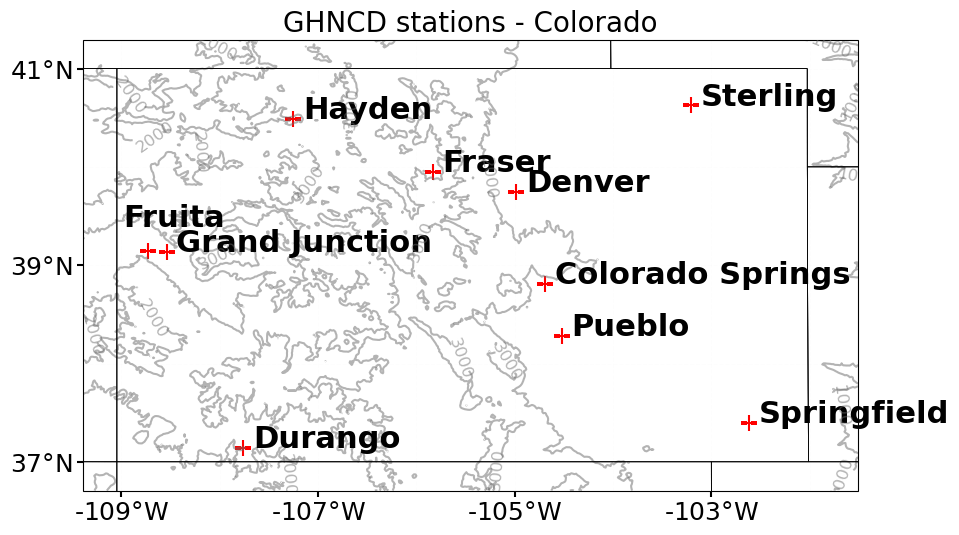

In [11]:
cmap=cmaps.BlGrYeOrReVi200
proj=ccrs.PlateCarree()
colors=cm.get_cmap('turbo',len(ds['station']))
#colors=cm.get_cmap('turbo',10)

fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(10,11),subplot_kw={'projection':proj})
cs=ax.contour(dsheight['lon'],dsheight['lat'],dsheight['z'],levels=np.arange(1000,6000,1000),colors='dimgrey',alpha=0.5)
ax.clabel(cs, inline=True, fmt='%d', fontsize=12)
for ip in range(0,len(ds['station'])):
  if Tlabel[ip] == 'Fruita': 
    ax.scatter(ds['longitude'][ip]+360,ds['latitude'][ip],marker='+',color='r',s=125)
    ax.text(ds['longitude'][ip]-0.25,ds['latitude'][ip]+0.25,f'{Tlabel[ip]}',color='k',size=22,weight='bold')
  else:
    ax.scatter(ds['longitude'][ip]+360,ds['latitude'][ip],marker='+',color='r',s=125)
    ax.text(ds['longitude'][ip]+0.1,ds['latitude'][ip],f'{Tlabel[ip]}',color='k',size=22,weight='bold')
grd = ax.gridlines(
draw_labels=False, 
color='gray', alpha=0.01, linestyle='--')

ax.set_xlabel('')
ax.set_ylabel('')
ax.add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
ax.tick_params(axis='both',direction='out',width=1.5,length=4)
ax.set_yticks(ax.get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
ax.set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax.get_yticks()],size=18)
ax.set_xticks(ax.get_xticks()[1:-1:2],crs=ccrs.PlateCarree())
ax.set_xticklabels([f'{round(ixx)}$\degree$W' for ixx in ax.get_xticks()],size=18)
ax.add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
ax.set_title('GHNCD stations - Colorado',fontsize=20)

# READ ERA5 interpolated on GHCND 's stations.

In [12]:
dsEtmin=xr.open_dataset(f'{datadir}/era5_daily_tmin_GHCND_CO.nc')
dsEtmin = dsEtmin.sel(time=ds['time'],drop=True)
dsEtmax=xr.open_dataset(f'{datadir}/era5_daily_tmax_GHCND_CO.nc')
dsEtmax = dsEtmax.sel(time=ds['time'],drop=True)
Etmin = dsEtmin['Tmin']* 9/5 + 32 # degC to degF
Etmax = dsEtmax['Tmax']* 9/5 + 32 # degC to degF

# READ NClimDrid interpolated on GHCND 's stations.

In [13]:
dsNtmin=xr.open_dataset(f'{datadir}/NClimGridDaily_daily_tmin_GHCND_CO.nc')
dsNtmin = dsNtmin.sel(time=ds['time'],drop=True)
dsNtmax=xr.open_dataset(f'{datadir}/NClimGridDaily_daily_tmax_GHCND_CO.nc')
dsNtmax = dsNtmax.sel(time=ds['time'],drop=True)

Ntmin = dsNtmin['Tmin']* 9/5 + 32 # degC to degF
Ntmax = dsNtmax['Tmax']* 9/5 + 32 # degC to degF

# Time matching GHCND and ERA5

In [14]:
#obs = functions_utils.remove_outliers_seasons(ds['TAVG'],2)

In [15]:
masktmin = xr.where(np.isnan(Otmin)==False,1,0)
masktmax = xr.where(np.isnan(Otmax)==False,1,0)

In [16]:
Etmin = Etmin.where(masktmin==1)
Ntmin = Ntmin.where(masktmin==1)
Etmax = Etmax.where(masktmax==1)
Ntmax = Ntmax.where(masktmax==1)

In [17]:
Etmin['time'] = Otmin['time']
Etmin['station'] = Otmin['station']
Ntmin['time'] = Otmin['time']
Ntmin['station'] = Otmin['station']
Etmax['time'] = Otmin['time']
Etmax['station'] = Otmin['station']
Ntmax['time'] = Otmin['time']
Ntmax['station'] = Otmin['station']

# Compute Coldest Tmin & Warmest Tmax

In [18]:
yearb = 1952
yeare = 2024

In [19]:
Octmin = xr.zeros_like(Otmin.groupby('time.year').mean('time'))*np.NAN
Octmax = xr.zeros_like(Otmax.groupby('time.year').mean('time'))*np.NAN
Ectmin = xr.zeros_like(Etmin.groupby('time.year').mean('time'))*np.NAN
Ectmax = xr.zeros_like(Etmax.groupby('time.year').mean('time'))*np.NAN
Nctmin = xr.zeros_like(Ntmin.groupby('time.year').mean('time'))*np.NAN
Nctmax = xr.zeros_like(Ntmax.groupby('time.year').mean('time'))*np.NAN
for iyear in np.arange(yearb,yeare+1):
  ##
  Omin = Otmin.sel(time=slice(f'{iyear-1}-09-28',f'{iyear}-10-04')) #
  Omin = Omin.rolling(time=5,center=True).mean('time')
  Omin = Omin.sel(time=slice(f'{iyear-1}-10-01',f'{iyear}-09-30'))
  Octmin.loc[{'year':iyear}] = Omin.min('time')
  #
  Omax = Otmax.sel(time=slice(f'{iyear-1}-09-28',f'{iyear}-10-04')) #
  Omax = Omax.rolling(time=5,center=True).mean('time')
  Omax = Omax.sel(time=slice(f'{iyear-1}-10-01',f'{iyear}-09-30'))
  Octmax.loc[{'year':iyear}] = Omax.max('time')
  ##
  Emin = Etmin.sel(time=slice(f'{iyear-1}-09-28',f'{iyear}-10-04')) #
  Emin = Emin.rolling(time=5,center=True).mean('time')
  Emin = Emin.sel(time=slice(f'{iyear-1}-10-01',f'{iyear}-09-30'))
  Ectmin.loc[{'year':iyear}] = Emin.min('time')
  #
  Emax = Etmax.sel(time=slice(f'{iyear-1}-09-28',f'{iyear}-10-04')) #
  Emax = Emax.rolling(time=5,center=True).mean('time')
  Emax = Emax.sel(time=slice(f'{iyear-1}-10-01',f'{iyear}-09-30'))
  Ectmax.loc[{'year':iyear}] = Emax.max('time')
  ##
  Nmin = Ntmin.sel(time=slice(f'{iyear-1}-09-28',f'{iyear}-10-04')) #
  Nmin = Nmin.rolling(time=5,center=True).mean('time')
  Nmin = Nmin.sel(time=slice(f'{iyear-1}-10-01',f'{iyear}-09-30'))
  Nctmin.loc[{'year':iyear}] = Nmin.min('time')
  #
  Nmax = Ntmax.sel(time=slice(f'{iyear-1}-09-28',f'{iyear}-10-04')) #
  Nmax = Nmax.rolling(time=5,center=True).mean('time')
  Nmax = Nmax.sel(time=slice(f'{iyear-1}-10-01',f'{iyear}-09-30'))
  Nctmax.loc[{'year':iyear}] = Nmax.max('time')

# Compute Trends 

In [20]:
Otrend_tmin = trend_dim(Octmin,'year')
Otrend_tmax = trend_dim(Octmax,'year')
Etrend_tmin = trend_dim(Ectmin,'year')
Etrend_tmax = trend_dim(Ectmax,'year')
Ntrend_tmin = trend_dim(Nctmin,'year')
Ntrend_tmax = trend_dim(Nctmax,'year')

In [21]:
  aij = Otrend_tmin['polyfit_coefficients'].sel(degree=1).isel(station=ip)
  bij = Otrend_tmin['polyfit_coefficients'].sel(degree=0).isel(station=ip)
  lines=Octmin['year'].where(np.isnan(Octmin.isel(station=ip))==False,drop=True)*aij.values + bij.values

In [22]:
lines

<xarray.DataArray 'year' (year: 23)>
array([ 6.78747826,  6.45095652,  6.11443478,  5.77791304,  5.4413913 ,
        5.10486957,  4.76834783,  4.43182609,  4.09530435,  3.75878261,
        3.42226087,  3.08573913,  2.74921739,  2.41269565,  2.07617391,
        1.73965217,  1.40313043,  1.0666087 ,  0.73008696,  0.39356522,
        0.05704348, -0.27947826, -0.616     ])
Coordinates:
  * year     (year) int64 1952 1953 1954 1955 1956 ... 1970 1971 1972 1973 1974
    station  <U11 'USW00093002'

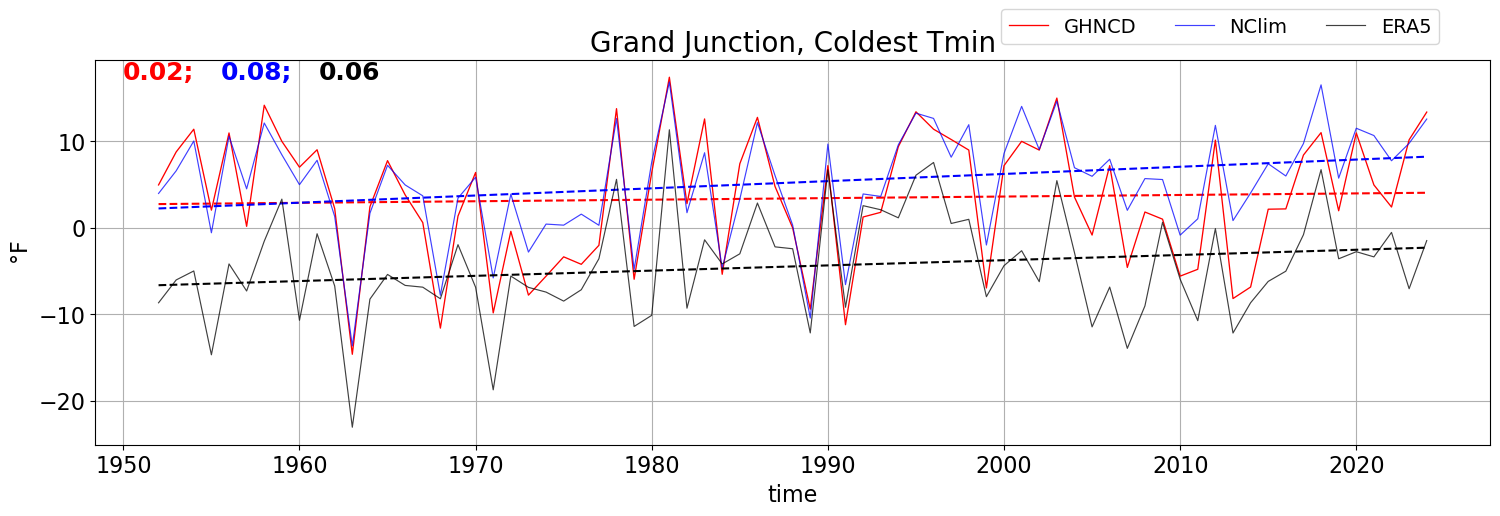

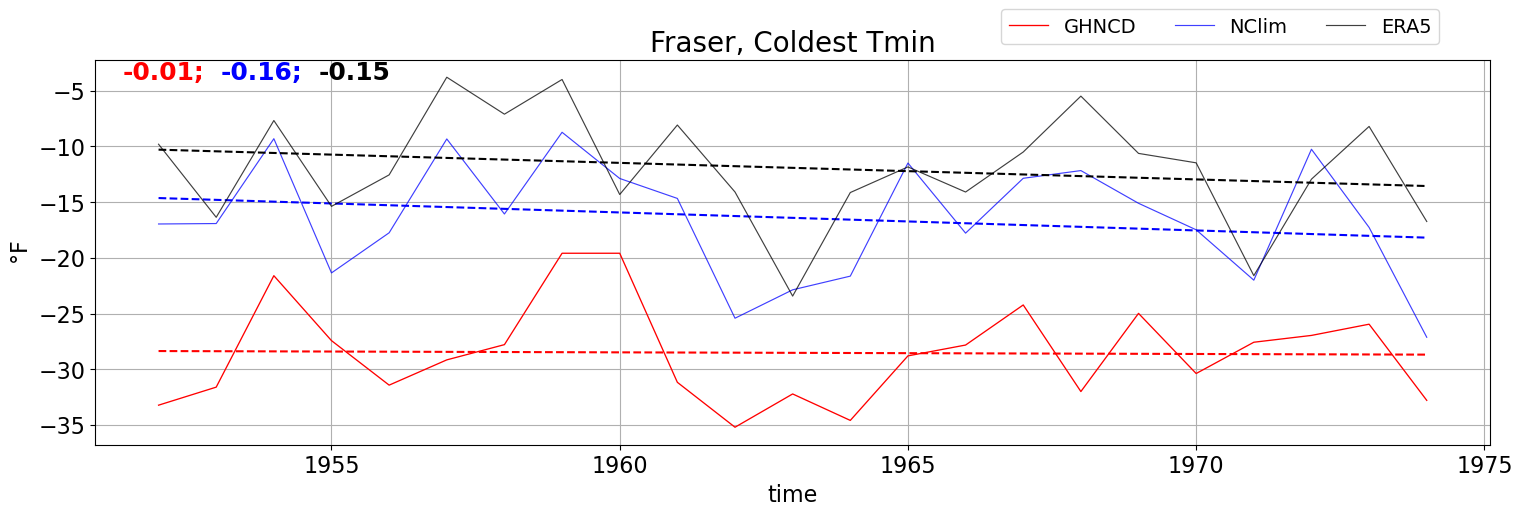

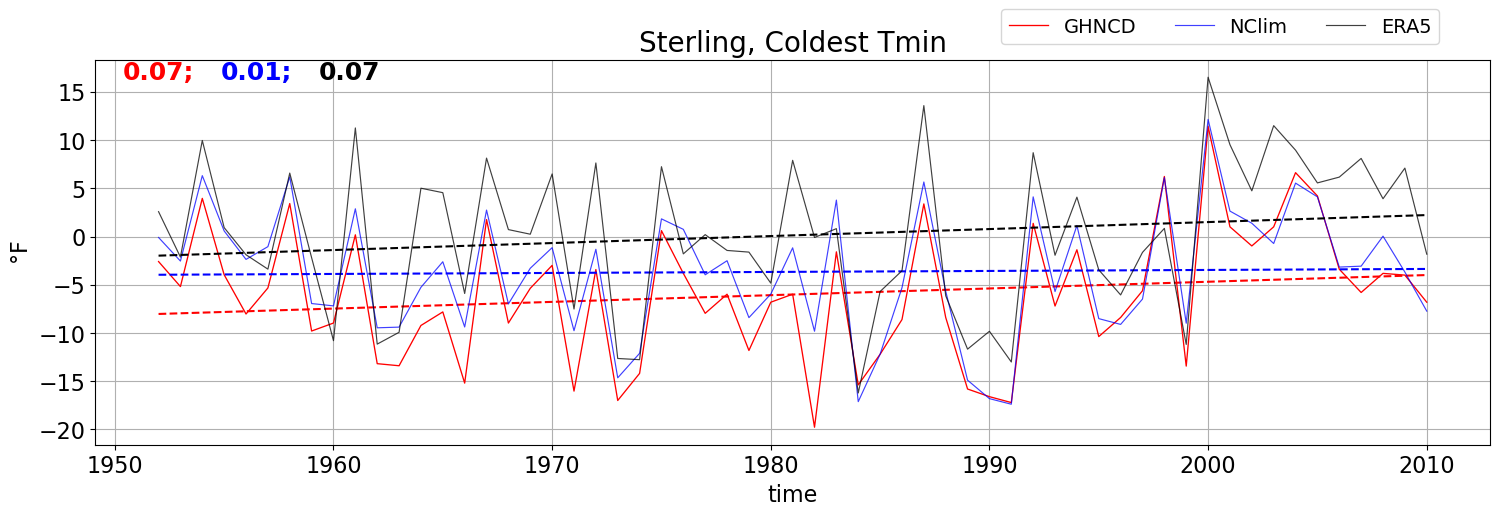

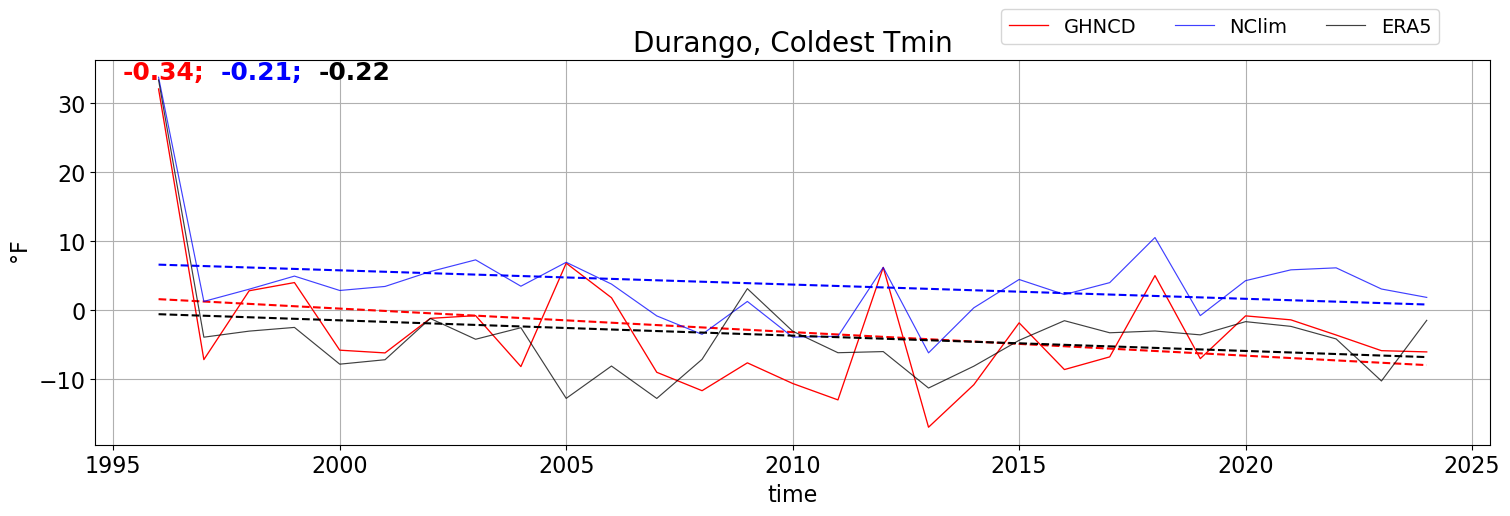

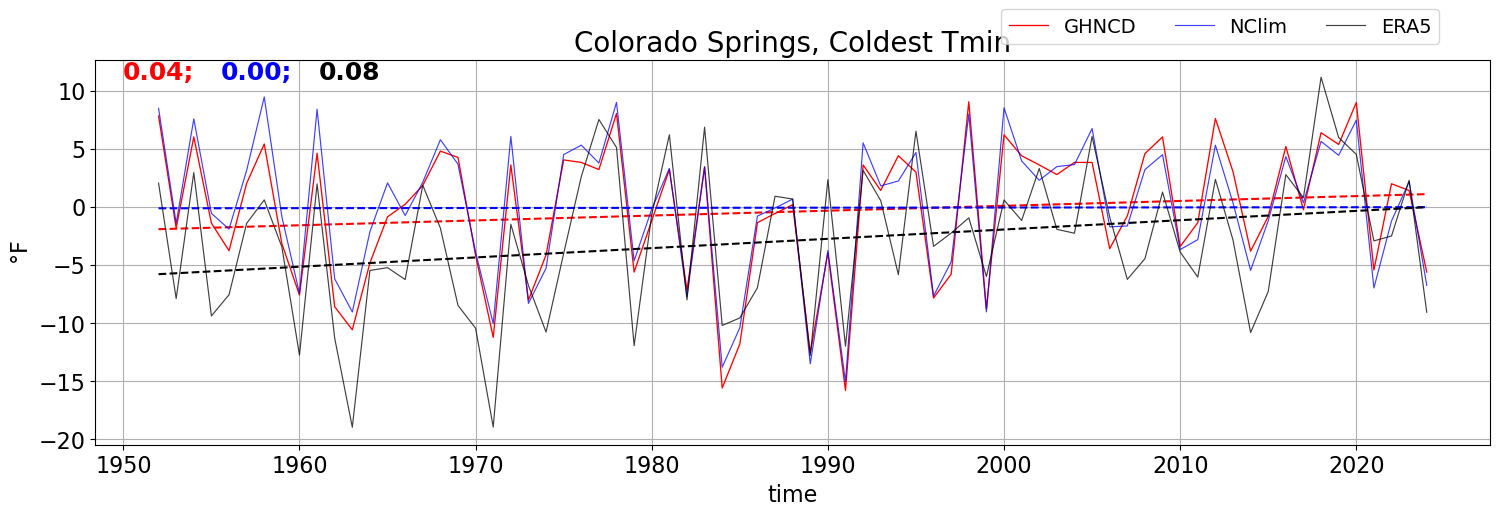

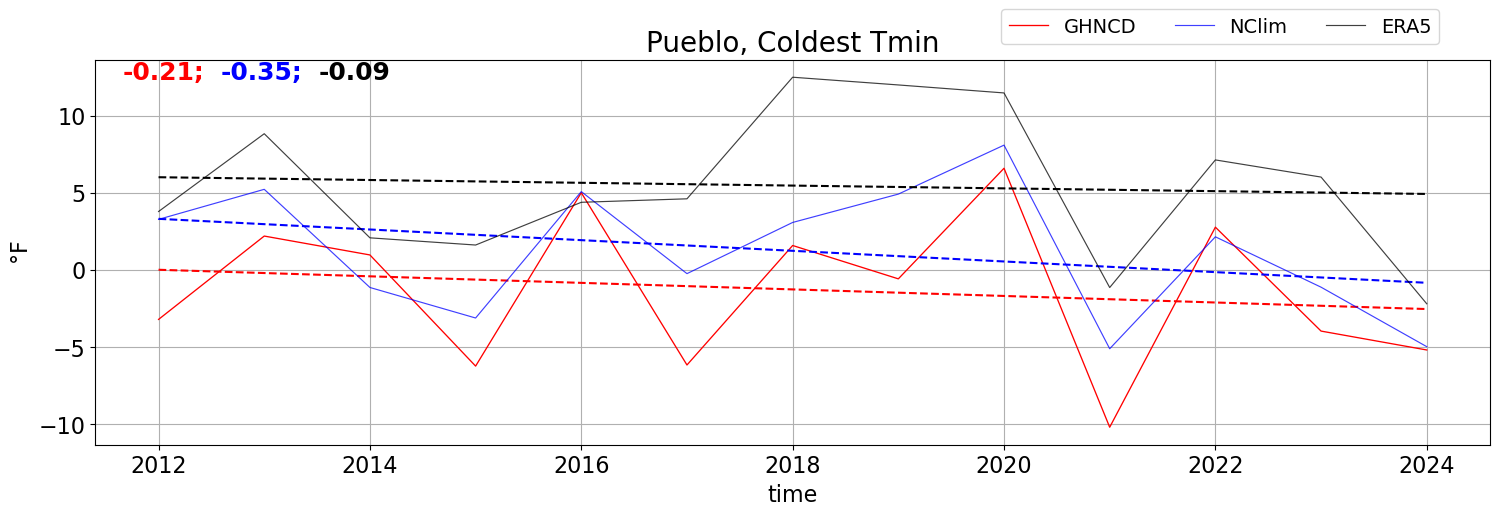

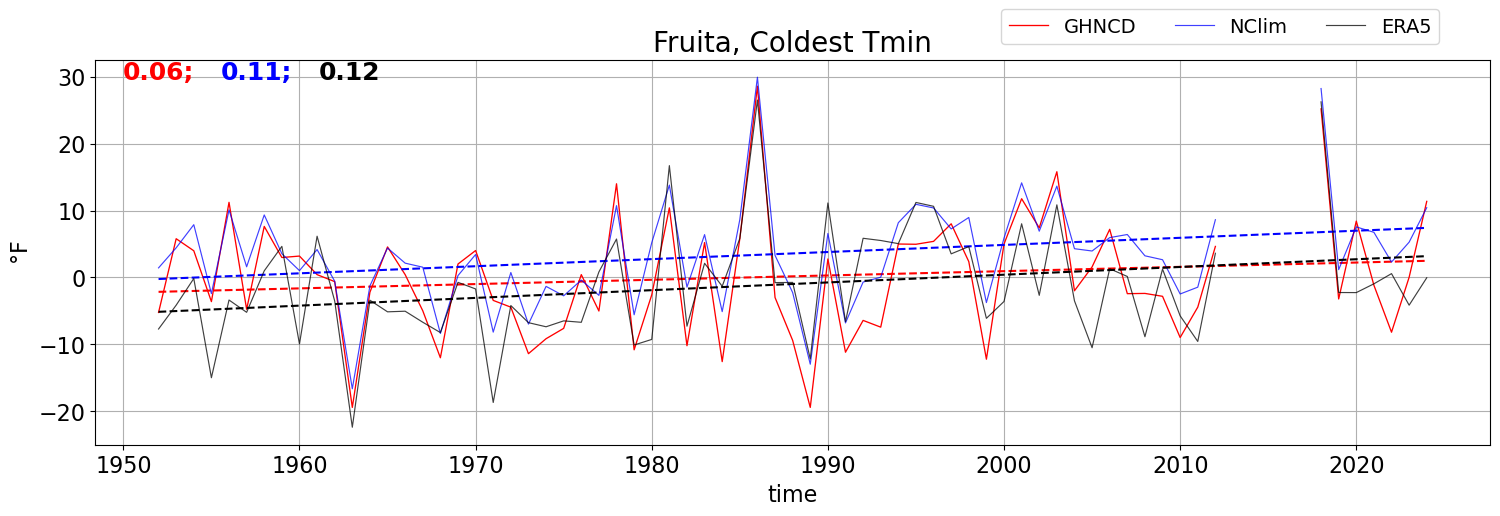

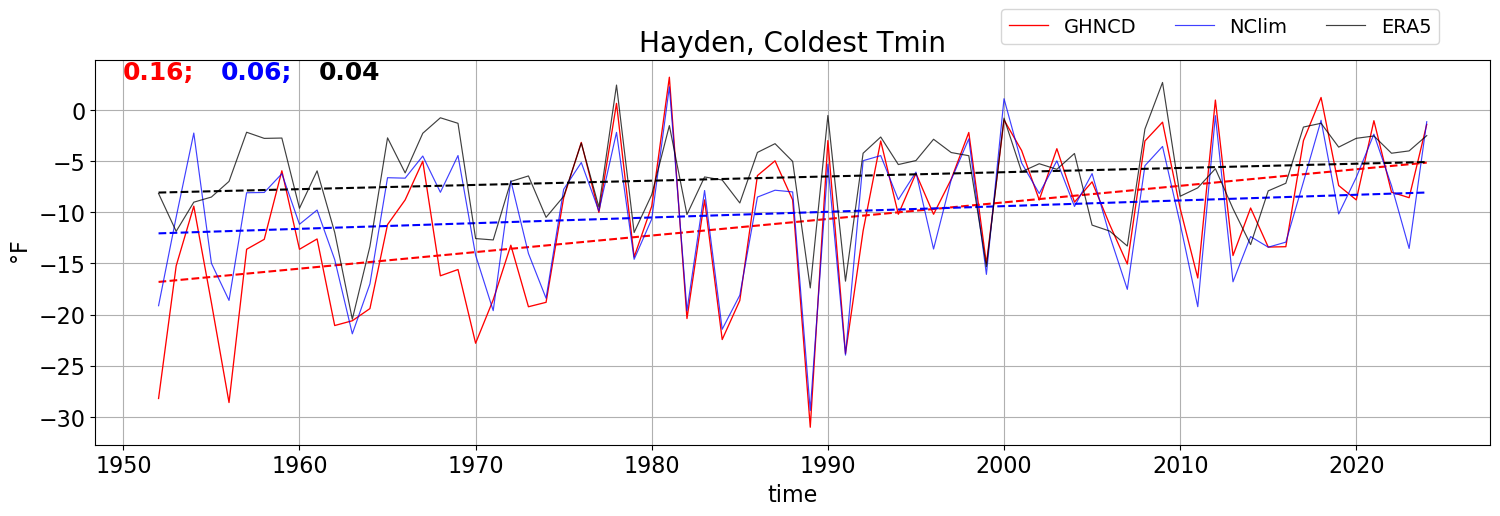

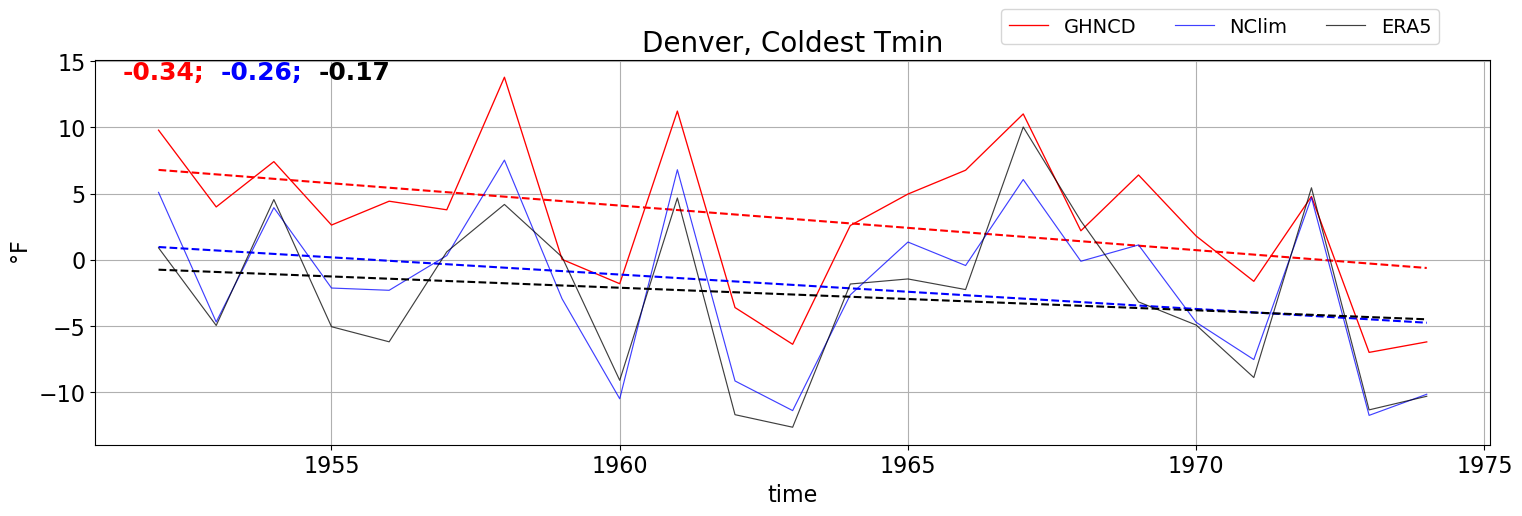

In [23]:
Tip = [0,1,2,3,4,5,6,7,9]
for ip in Tip:
  fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(18,5))
  #
  ax.plot(Octmin['year'],Octmin.isel(station=ip),color='r',linewidth=0.95,label='GHNCD')
  aij = Otrend_tmin['polyfit_coefficients'].sel(degree=1).isel(station=ip)
  bij = Otrend_tmin['polyfit_coefficients'].sel(degree=0).isel(station=ip)
  lines=Octmin['year'].where(np.isnan(Octmin.isel(station=ip))==False,drop=True)*aij.values + bij.values
  ax.plot(lines.year,lines,color='r',linestyle='--')
  ax.text(0.02,0.95,f'{aij.values:0.2f};',color='r',size=18,weight='bold',transform=ax.transAxes)
  #
  ax.plot(Octmin['year'],Nctmin.isel(station=ip),color='b',linewidth=0.85,label='NClim',alpha=0.75)
  aij = Ntrend_tmin['polyfit_coefficients'].sel(degree=1).isel(station=ip)
  bij = Ntrend_tmin['polyfit_coefficients'].sel(degree=0).isel(station=ip)
  lines=lines.year*aij.values + bij.values
  ax.plot(lines.year,lines,color='b',linestyle='--')
  ax.text(0.09,0.95,f'{aij.values:0.2f};',color='b',size=18,weight='bold',transform=ax.transAxes)
  #
  ax.plot(Octmin['year'],Ectmin.isel(station=ip),color='k',linewidth=0.85,label='ERA5',alpha=0.75)
  aij = Etrend_tmin['polyfit_coefficients'].sel(degree=1).isel(station=ip)
  bij = Etrend_tmin['polyfit_coefficients'].sel(degree=0).isel(station=ip)
  lines=lines.year*aij.values + bij.values
  ax.plot(lines.year,lines,color='k',linestyle='--')
  ax.text(0.16,0.95,f'{aij.values:0.2f}',color='k',size=18,weight='bold',transform=ax.transAxes)
  #
  ax.tick_params(labelsize=16)
  handles, labels = ax.get_legend_handles_labels()
  fig.legend(handles, labels, loc='upper center',ncol=3,bbox_to_anchor=(0.75,1.0),prop={'size': 14})
  plt.grid()
  plt.ylabel(units,fontsize=16)  
  plt.xlabel('time',fontsize=16)
  plt.title(f'{Tlabel[ip]}, Coldest Tmin',fontsize=20)

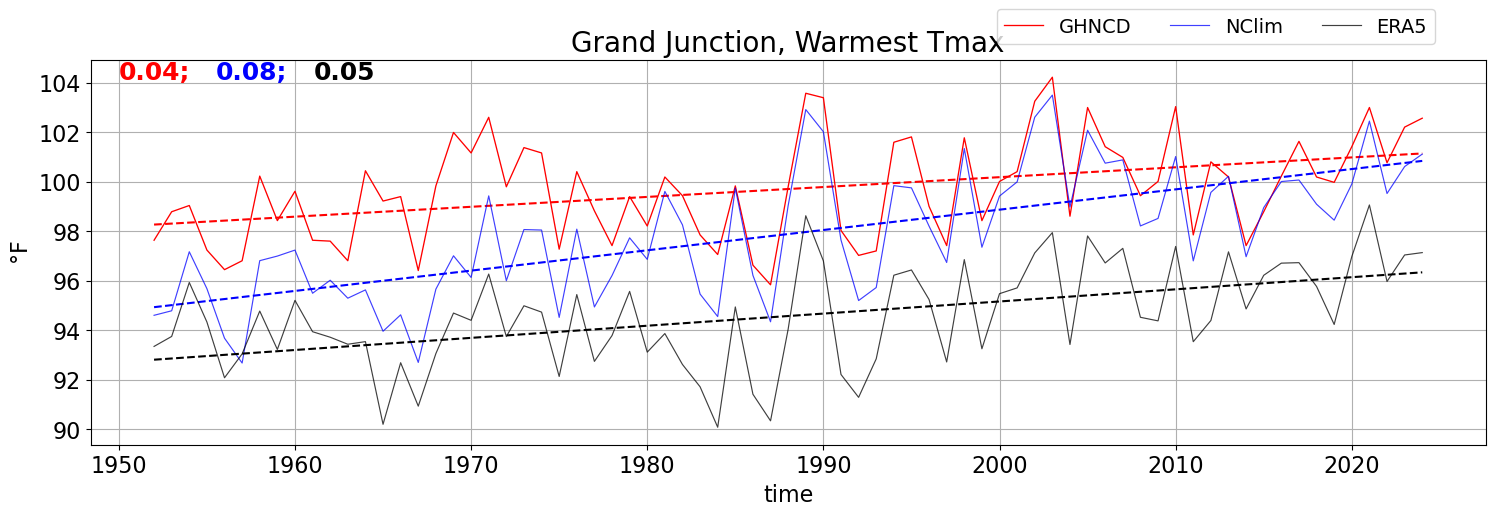

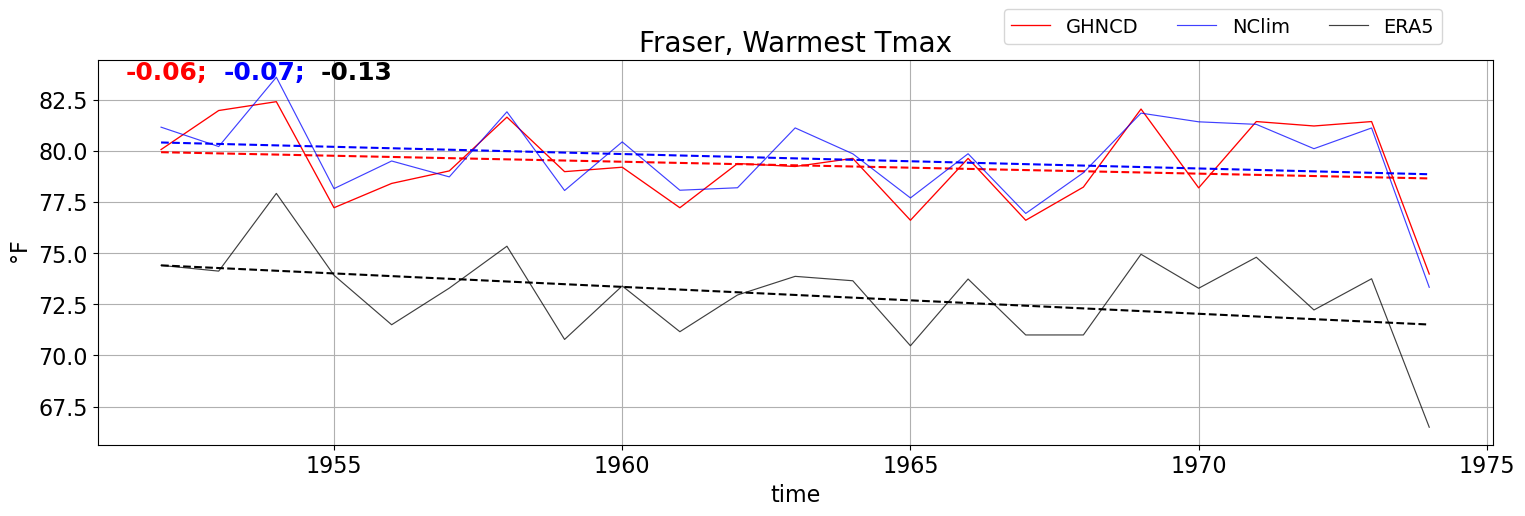

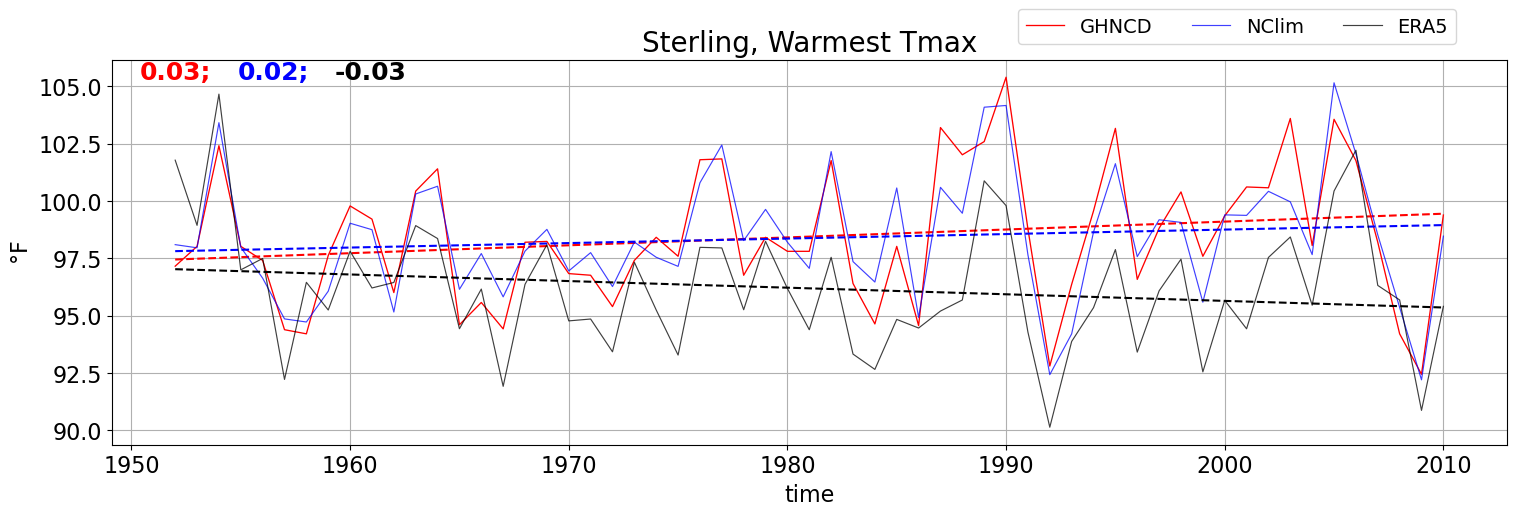

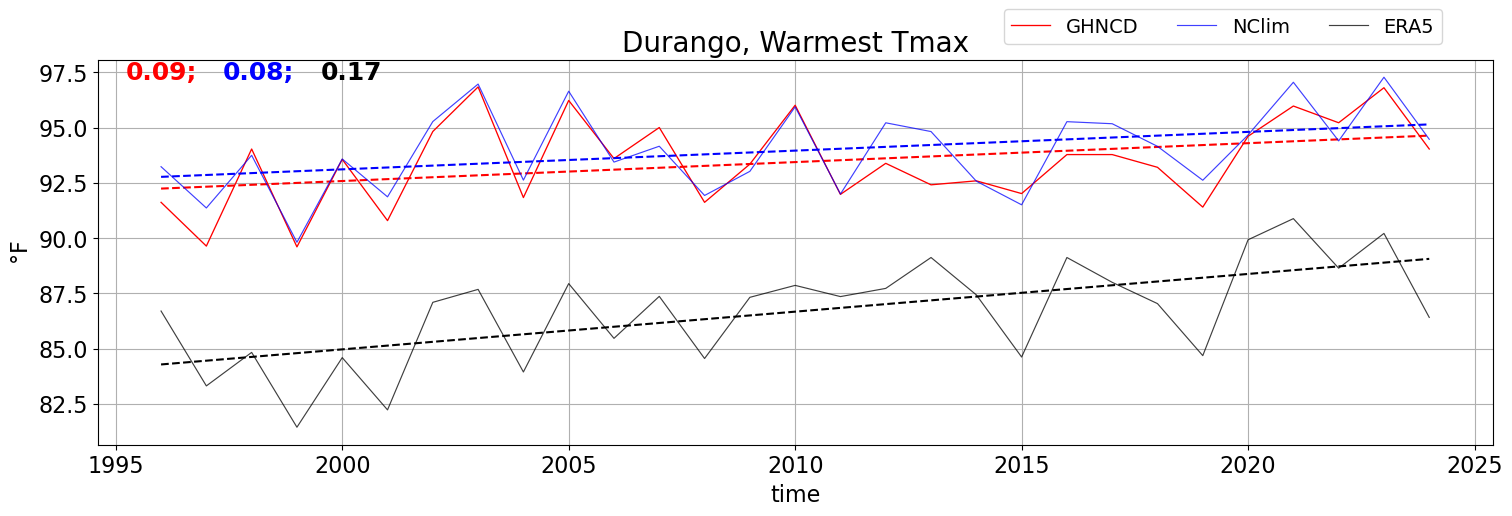

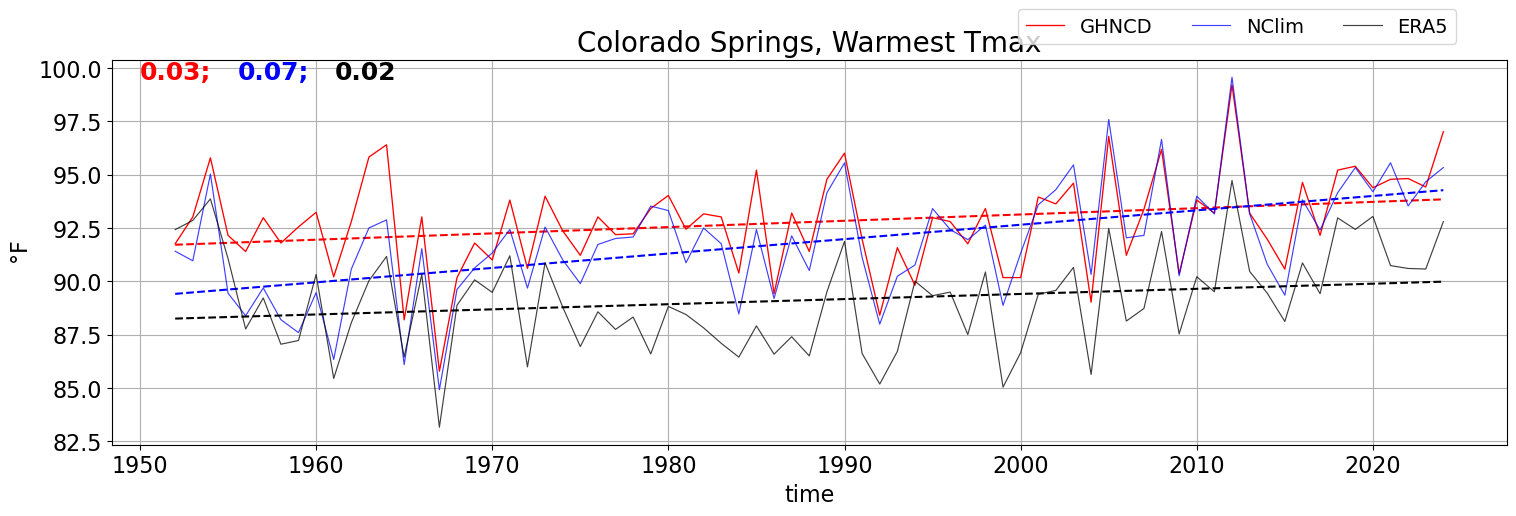

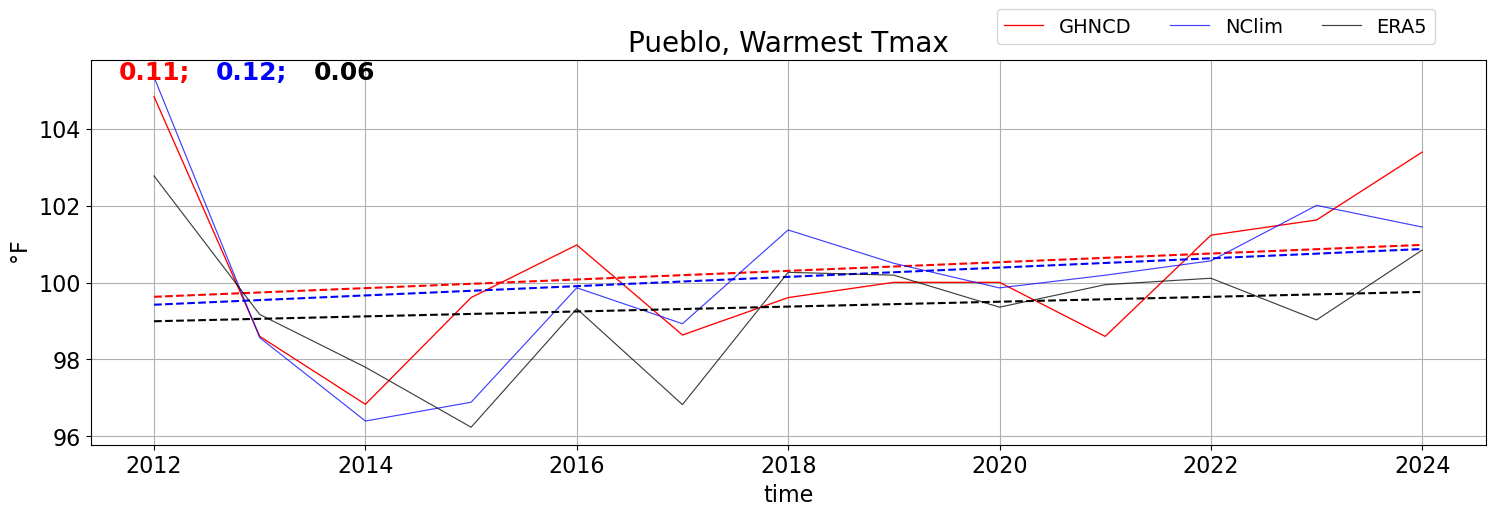

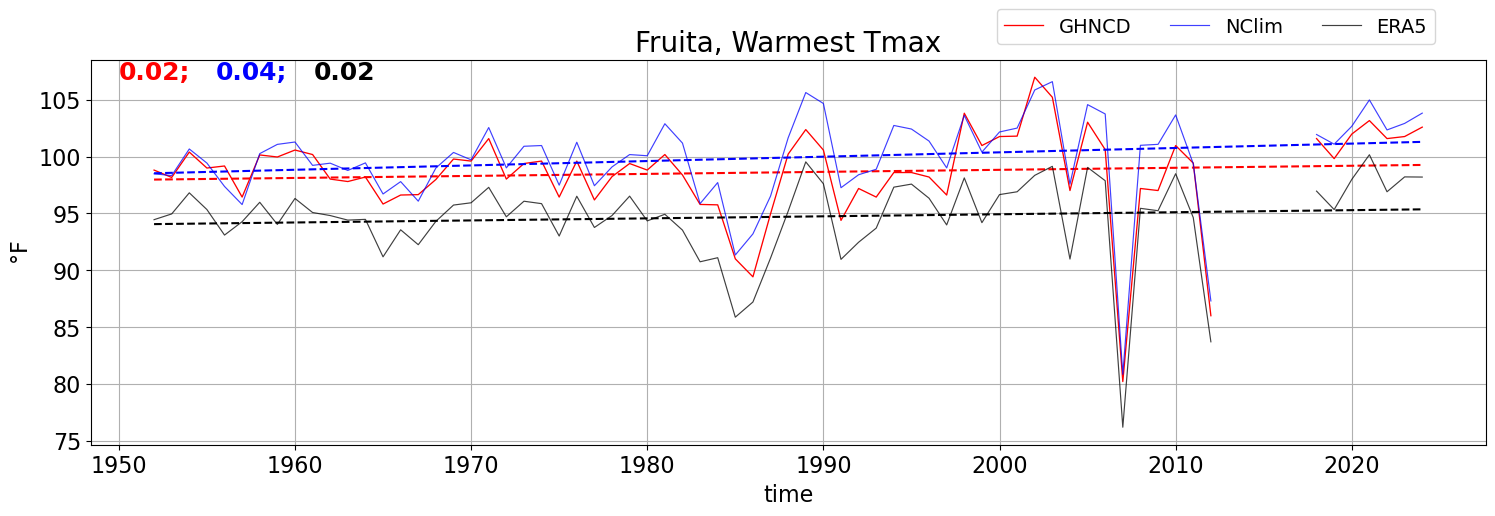

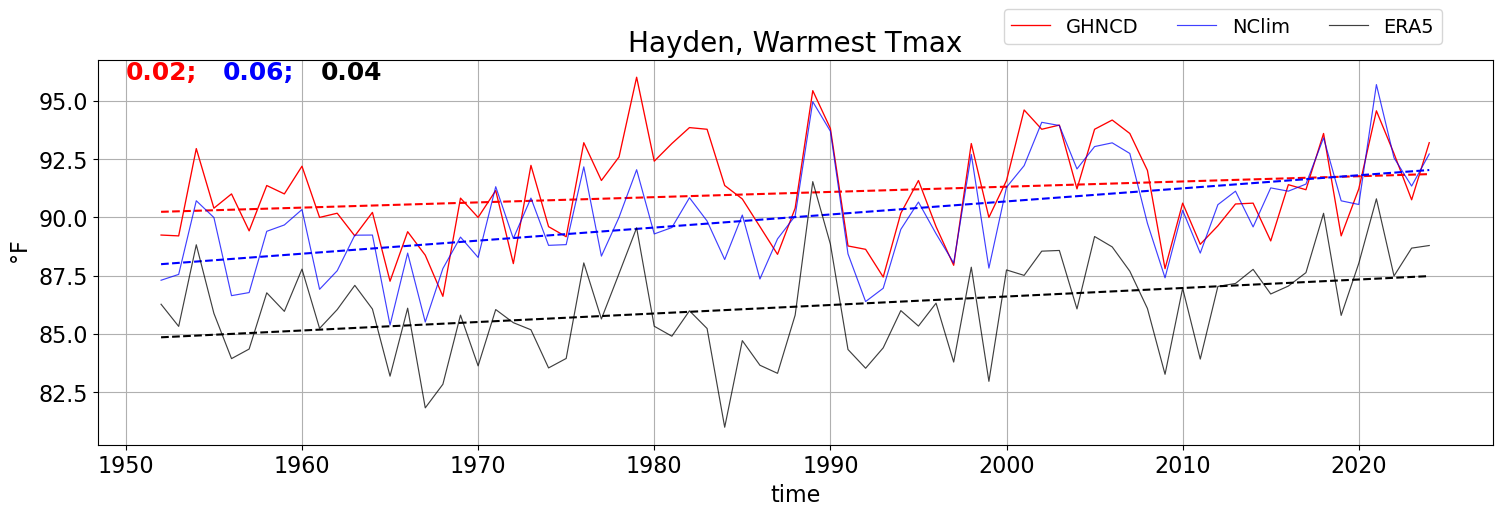

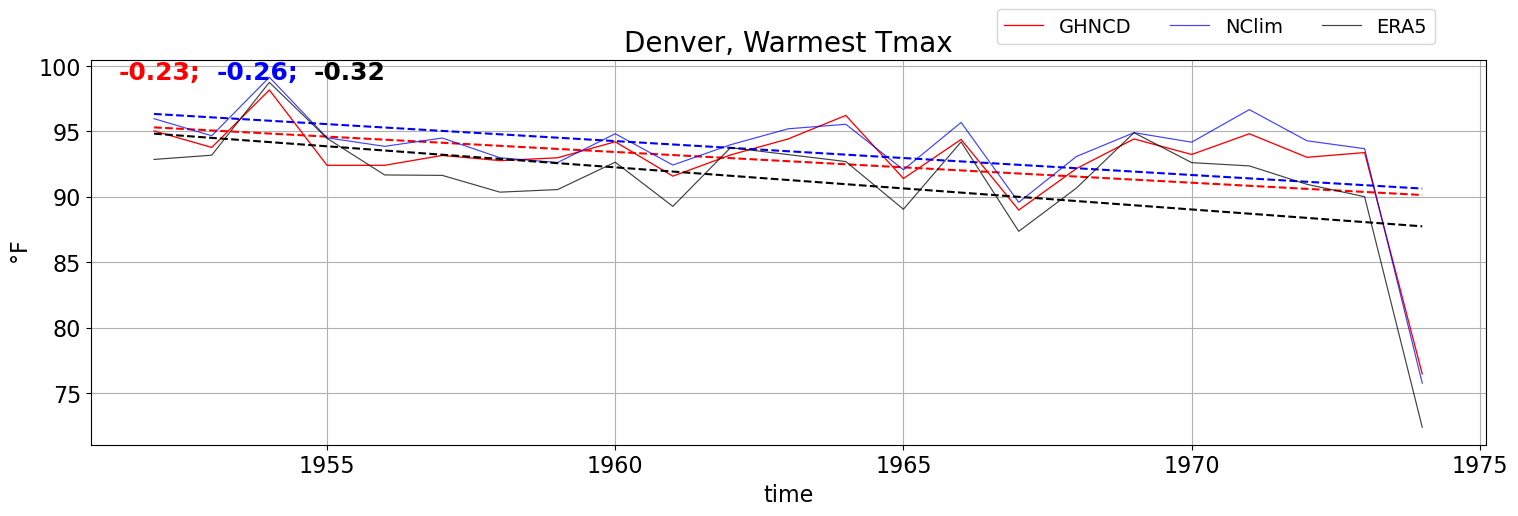

In [24]:
Tip = [0,1,2,3,4,5,6,7,9]
for ip in Tip:
  fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(18,5))
  #
  ax.plot(Octmax['year'],Octmax.isel(station=ip),color='r',linewidth=0.95,label='GHNCD')
  aij = Otrend_tmax['polyfit_coefficients'].sel(degree=1).isel(station=ip)
  bij = Otrend_tmax['polyfit_coefficients'].sel(degree=0).isel(station=ip)
  lines=Octmax['year'].where(np.isnan(Octmax.isel(station=ip))==False,drop=True)*aij.values + bij.values
  ax.plot(lines.year,lines,color='r',linestyle='--')
  ax.text(0.02,0.95,f'{aij.values:0.2f};',color='r',size=18,weight='bold',transform=ax.transAxes)
  #
  ax.plot(Octmax['year'],Nctmax.isel(station=ip),color='b',linewidth=0.85,label='NClim',alpha=0.75)
  aij = Ntrend_tmax['polyfit_coefficients'].sel(degree=1).isel(station=ip)
  bij = Ntrend_tmax['polyfit_coefficients'].sel(degree=0).isel(station=ip)
  lines=lines.year*aij.values + bij.values
  ax.plot(lines.year,lines,color='b',linestyle='--')
  ax.text(0.09,0.95,f'{aij.values:0.2f};',color='b',size=18,weight='bold',transform=ax.transAxes)
  #
  ax.plot(Octmax['year'],Ectmax.isel(station=ip),color='k',linewidth=0.85,label='ERA5',alpha=0.75)
  aij = Etrend_tmax['polyfit_coefficients'].sel(degree=1).isel(station=ip)
  bij = Etrend_tmax['polyfit_coefficients'].sel(degree=0).isel(station=ip)
  lines=lines.year*aij.values + bij.values
  ax.plot(lines.year,lines,color='k',linestyle='--')
  ax.text(0.16,0.95,f'{aij.values:0.2f}',color='k',size=18,weight='bold',transform=ax.transAxes)
  #
  ax.tick_params(labelsize=16)
  handles, labels = ax.get_legend_handles_labels()
  fig.legend(handles, labels, loc='upper center',ncol=3,bbox_to_anchor=(0.75,1.0),prop={'size': 14})
  plt.grid()
  plt.ylabel(units,fontsize=16)  
  plt.xlabel('time',fontsize=16)
  plt.title(f'{Tlabel[ip]}, Warmest Tmax',fontsize=20)

# Table

In [25]:
rmse_OEmin = xr.zeros_like(Octmin.mean('year'))*np.nan ; rmse_ONmin = xr.zeros_like(Octmin.mean('year'))*np.nan
corr_OEmin = xr.zeros_like(Octmin.mean('year'))*np.nan ; corr_ONmin = xr.zeros_like(Octmin.mean('year'))*np.nan
mbia_OEmin = xr.zeros_like(Octmin.mean('year'))*np.nan ; mbia_ONmin = xr.zeros_like(Octmin.mean('year'))*np.nan

rmse_OEmax = xr.zeros_like(Octmax.mean('year'))*np.nan ; rmse_ONmax = xr.zeros_like(Octmax.mean('year'))*np.nan
corr_OEmax = xr.zeros_like(Octmax.mean('year'))*np.nan ; corr_ONmax = xr.zeros_like(Octmax.mean('year'))*np.nan
mbia_OEmax = xr.zeros_like(Octmax.mean('year'))*np.nan ; mbia_ONmax = xr.zeros_like(Octmax.mean('year'))*np.nan 

## Compute RMSE

In [37]:
for ip in range(0,len(ds['station'])):
    rmse_OEmin[ip] = np.sqrt(np.nanmean((Otmin.isel(station=ip) - Etmin.isel(station=ip))**2))
    rmse_OEmax[ip] = np.sqrt(np.nanmean((Otmax.isel(station=ip) - Etmax.isel(station=ip))**2))
    rmse_ONmin[ip] = np.sqrt(np.nanmean((Otmin.isel(station=ip) - Ntmin.isel(station=ip))**2))
    rmse_ONmax[ip] = np.sqrt(np.nanmean((Otmax.isel(station=ip) - Ntmax.isel(station=ip))**2))     

/tmp/ipykernel_2944522/1969842851.py:2: RuntimeWarning: Mean of empty slice
  rmse_OEmin[ip] = np.sqrt(np.nanmean((Otmin.isel(station=ip) - Etmin.isel(station=ip))**2))
/tmp/ipykernel_2944522/1969842851.py:3: RuntimeWarning: Mean of empty slice
  rmse_OEmax[ip] = np.sqrt(np.nanmean((Otmax.isel(station=ip) - Etmax.isel(station=ip))**2))
/tmp/ipykernel_2944522/1969842851.py:4: RuntimeWarning: Mean of empty slice
  rmse_ONmin[ip] = np.sqrt(np.nanmean((Otmin.isel(station=ip) - Ntmin.isel(station=ip))**2))
/tmp/ipykernel_2944522/1969842851.py:5: RuntimeWarning: Mean of empty slice
  rmse_ONmax[ip] = np.sqrt(np.nanmean((Otmax.isel(station=ip) - Ntmax.isel(station=ip))**2))


## Compute Mean Bias

In [38]:
for ip in range(0,len(ds['station'])):
    mbia_OEmin[ip] = np.nanmean(Octmin.isel(station=ip)) - np.nanmean(Ectmin.isel(station=ip))
    mbia_OEmax[ip] = np.nanmean(Octmax.isel(station=ip)) - np.nanmean(Ectmax.isel(station=ip))
    mbia_ONmin[ip] = np.nanmean(Octmin.isel(station=ip)) - np.nanmean(Nctmin.isel(station=ip))
    mbia_ONmax[ip] = np.nanmean(Octmax.isel(station=ip)) - np.nanmean(Nctmax.isel(station=ip))

/tmp/ipykernel_2944522/891582869.py:2: RuntimeWarning: Mean of empty slice
  mbia_OEmin[ip] = np.nanmean(Octmin.isel(station=ip)) - np.nanmean(Ectmin.isel(station=ip))
/tmp/ipykernel_2944522/891582869.py:3: RuntimeWarning: Mean of empty slice
  mbia_OEmax[ip] = np.nanmean(Octmax.isel(station=ip)) - np.nanmean(Ectmax.isel(station=ip))
/tmp/ipykernel_2944522/891582869.py:4: RuntimeWarning: Mean of empty slice
  mbia_ONmin[ip] = np.nanmean(Octmin.isel(station=ip)) - np.nanmean(Nctmin.isel(station=ip))
/tmp/ipykernel_2944522/891582869.py:5: RuntimeWarning: Mean of empty slice
  mbia_ONmax[ip] = np.nanmean(Octmax.isel(station=ip)) - np.nanmean(Nctmax.isel(station=ip))


## Compute Correlation

In [39]:
for ip in range(0,len(ds['station'])):
    xxxmin = np.where(np.isnan(Octmin.isel(station=ip))==False)[0]
    xxxmax = np.where(np.isnan(Octmax.isel(station=ip))==False)[0]
    corr_OEmin[ip] = np.corrcoef(Octmin.isel(station=ip)[xxxmin],Ectmin.isel(station=ip)[xxxmin])[0][1]
    corr_OEmax[ip] = np.corrcoef(Octmax.isel(station=ip)[xxxmax],Ectmax.isel(station=ip)[xxxmax])[0][1]
    corr_ONmin[ip] = np.corrcoef(Octmin.isel(station=ip)[xxxmin],Nctmin.isel(station=ip)[xxxmin])[0][1]
    corr_ONmax[ip] = np.corrcoef(Octmax.isel(station=ip)[xxxmax],Nctmax.isel(station=ip)[xxxmax])[0][1]

/home/ghervieux/.conda/envs/Newgaelle/lib/python3.11/site-packages/numpy/lib/function_base.py:520: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/home/ghervieux/.conda/envs/Newgaelle/lib/python3.11/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/home/ghervieux/.conda/envs/Newgaelle/lib/python3.11/site-packages/numpy/lib/function_base.py:2889: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/home/ghervieux/.conda/envs/Newgaelle/lib/python3.11/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/home/ghervieux/.conda/envs/Newgaelle/lib/python3.11/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


In [40]:
dsout = rmse_OEmin.to_dataset(name='rmse_OEmin')
dsout = dsout.merge({'rmse_ONmin':rmse_ONmin,'mbia_OEmin':mbia_OEmin, 'mbia_ONmin':mbia_ONmin, 'corr_OEmin':corr_OEmin, 'corr_ONmin':corr_ONmin})
dsout = dsout.merge({'Otrend_tmin':Otrend_tmin['polyfit_coefficients'].sel(degree=1)})
dsout = dsout.merge({'Etrend_tmin':Etrend_tmin['polyfit_coefficients'].sel(degree=1)})
dsout = dsout.merge({'Ntrend_tmin':Ntrend_tmin['polyfit_coefficients'].sel(degree=1)})
dsout = dsout.merge({'rmse_OEmax':rmse_OEmax, 'rmse_ONmax':rmse_ONmax, 'mbia_OEmax':mbia_OEmax, 'mbia_ONmax':mbia_ONmax, 'corr_OEmax':corr_OEmax, 'corr_ONmax':corr_ONmax})
dsout = dsout.merge({'Otrend_tmax':Otrend_tmax['polyfit_coefficients'].sel(degree=1)})
dsout = dsout.merge({'Etrend_tmax':Etrend_tmax['polyfit_coefficients'].sel(degree=1)})
dsout = dsout.merge({'Ntrend_tmax':Ntrend_tmax['polyfit_coefficients'].sel(degree=1)})

In [41]:
dsout['station']=Tlabel
dsout = dsout.drop('degree')

In [42]:
df = dsout.to_dataframe()

In [43]:
df = df.transpose()

In [44]:
df['diagnostic'] = ['rmse (\u00B0F)','rmse (\u00B0F)','bias (\u00B0F)','bias (\u00B0F)','correlation','correlation',\
                    'trend (\u00B0F/year)','trend (\u00B0F/year)','trend (\u00B0F/year)',\
                    'rmse (\u00B0F)','rmse (\u00B0F)','bias (\u00B0F)','bias (\u00B0F)','correlation','correlation',\
                    'trend (\u00B0F/year)','trend (\u00B0F/year)','trend (\u00B0F/year)']
df['model'] = ['Obs/ERA5','Obs/NClim','Obs/ERA5','Obs/NClim','Obs/ERA5','Obs/NClim','Obs','ERA5','NClim',\
               'Obs/ERA5','Obs/NClim','Obs/ERA5','Obs/NClim','Obs/ERA5','Obs/NClim','Obs','ERA5','NClim']
df['variable'] = ['Coldest Tmin','Coldest Tmin','Coldest Tmin','Coldest Tmin','Coldest Tmin','Coldest Tmin','Coldest Tmin','Coldest Tmin','Coldest Tmin',
                  'Warmest Tmax','Warmest Tmax','Warmest Tmax','Warmest Tmax','Warmest Tmax','Warmest Tmax','Warmest Tmax','Warmest Tmax','Warmest Tmax']

In [64]:
table = pd.pivot_table(df,  index=['variable', 'diagnostic','model'])
table_style = table.style
styled_table = table_style.format('{:.2f}')
styled_table